# 🏋️ Análisis de Cancelación de Clientes - Model Fitness

## Descripción del Proyecto

La cadena de gimnasios **Model Fitness** está desarrollando una estrategia de interacción con clientes basada en datos analíticos. Uno de los problemas más comunes que enfrentan los gimnasios es la pérdida de clientes (*churn*). Este proyecto analiza los perfiles digitalizados de los clientes para elaborar una estrategia de retención.

---

## 🎯 Objetivos

- Predecir la probabilidad de cancelación para el próximo mes para cada cliente.
- Elaborar perfiles de usuarios típicos mediante segmentación por clústeres.
- Analizar los factores que más impactan la cancelación.
- Proponer recomendaciones accionables para mejorar la retención de clientes.

---

## 🗂️ Dataset

El archivo `gym_churn_us.csv` contiene datos sobre la cancelación de un mes y la información del mes anterior:

| Variable | Descripción |
|----------|-------------|
| `Churn` | Variable objetivo: cancelación del mes (1 = sí, 0 = no) |
| `gender` | Género del usuario (binario) |
| `Near_Location` | Si vive/trabaja cerca del gimnasio |
| `Partner` | Si trabaja en empresa asociada con descuento |
| `Promo_friends` | Si se inscribió mediante promoción "trae a un amigo" |
| `Phone` | Si proporcionó número de teléfono |
| `Contract_period` | Duración del contrato (meses) |
| `Group_visits` | Si participa en clases grupales |
| `Age` | Edad del cliente |
| `Avg_additional_charges_total` | Gasto promedio en servicios adicionales (USD) |
| `Month_to_end_contract` | Meses restantes para fin de contrato |
| `Lifetime` | Tiempo total como cliente (meses) |
| `Avg_class_frequency_total` | Frecuencia promedio histórica de clases por semana |
| `Avg_class_frequency_current_month` | Frecuencia de clases en el último mes |


In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

## 1. Carga y Exploración Inicial de Datos

In [2]:
# Cargar datos
df_gym = pd.read_csv("gym_churn_us.csv")
print('Información de la tabla df_gym:')
df_gym.info()
df_gym.sample(10)

Información de la tabla df_gym:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_tota

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
982,0,1,0,0,0,1,0,30,107.730507,1.0,0,1.188584,1.481935,1
2983,1,1,0,0,1,1,0,29,75.538085,1.0,0,1.700321,1.283061,1
3229,1,1,1,1,0,12,1,28,100.405907,10.0,3,1.150820,1.154683,0
541,0,1,1,0,1,6,0,28,100.815447,6.0,5,2.559317,2.544481,0
2901,0,1,0,0,0,1,1,31,29.953094,1.0,4,2.575846,2.568086,0
662,1,1,0,0,1,1,0,24,121.742941,1.0,1,0.827964,0.056958,1
2280,1,1,0,0,1,1,0,29,153.508168,1.0,2,2.672211,2.592440,0
659,1,1,1,1,1,6,0,29,105.494160,6.0,1,1.831515,1.573922,0
292,1,1,0,1,1,12,1,28,42.117378,11.0,5,2.203083,2.149543,0
1593,1,1,0,0,1,1,1,26,41.338087,1.0,9,1.092107,0.966535,0


Al revisar la tabla `df_gym` se observa que está bien estructurada y lista para el análisis:

**Estructura:**
- 4,000 registros y 14 columnas.
- Sin valores nulos en ninguna columna.

**Tipos de datos:**
- 10 columnas de tipo `int64` y 4 de tipo `float64`.

**Observaciones:**
- `Churn` es la variable objetivo, codificada como 1 (canceló) y 0 (permaneció).
- `gender` está codificada como 0 y 1. No se tiene claridad sobre cuál valor corresponde a cada género — sería útil solicitar la documentación del indicador para considerarlo en el análisis.
- Las variables `Near_Location`, `Partner`, `Promo_friends`, `Phone` y `Group_visits` son binarias (1 = sí, 0 = no).


## 2. Análisis Exploratorio de Datos (EDA)

In [3]:
# Verificar duplicados
print(f"Filas duplicadas: {df_gym.duplicated().sum()}")

Filas duplicadas: 0


In [4]:
# Verificar valores faltantes
print("Valores faltantes por columna:")
print(df_gym.isnull().sum())

Valores faltantes por columna:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [5]:
# Verificar consistencia en columnas binarias
categorical_columns = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits', 'Churn']
print("Valores únicos en columnas binarias:")
for col in categorical_columns:
    print(f"  {col}: {df_gym[col].unique()}")

print()
print("Estadísticas descriptivas de columnas numéricas:")
print(df_gym.describe().to_string(line_width=300))

Valores únicos en columnas binarias:
  gender: [1 0]
  Near_Location: [1 0]
  Partner: [1 0]
  Promo_friends: [1 0]
  Phone: [0 1]
  Group_visits: [1 0]
  Churn: [0 1]

Estadísticas descriptivas de columnas numéricas:
            gender  Near_Location      Partner  Promo_friends        Phone  Contract_period  Group_visits          Age  Avg_additional_charges_total  Month_to_end_contract     Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_month        Churn
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000      4000.000000   4000.000000  4000.000000                   4000.000000            4000.000000  4000.000000                4000.000000                        4000.000000  4000.000000
mean      0.510250       0.845250     0.486750       0.308500     0.903500         4.681250      0.412250    29.184250                    146.943728               4.322750     3.724750                   1.879020                           1.767052     0.265250
st

**Columnas binarias:** Todas presentan únicamente valores 0 y 1 — correctamente codificadas, sin valores inconsistentes.

**Distribuciones destacadas:**
- `Phone`: promedio de 0.90 → el 90% de los clientes proporcionó su número.
- `Promo_friends`: promedio de 0.31 → solo el 31% usó la promoción "trae a un amigo".

**Variables numéricas:**
- `Age`: entre 18 y 41 años, media de 29.18. Rango razonable para un gimnasio orientado a adultos jóvenes.
- `Contract_period`: media de 4.68 meses con desviación estándar alta (4.55), lo que indica gran variedad en los períodos contratados — muchos clientes optan por contratos cortos.


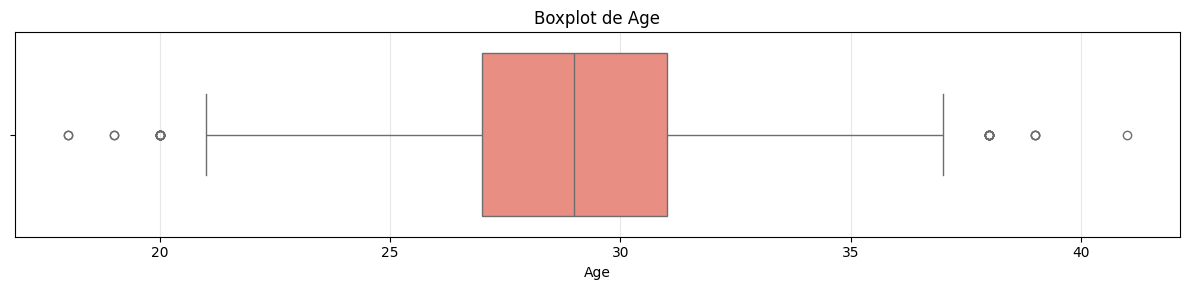

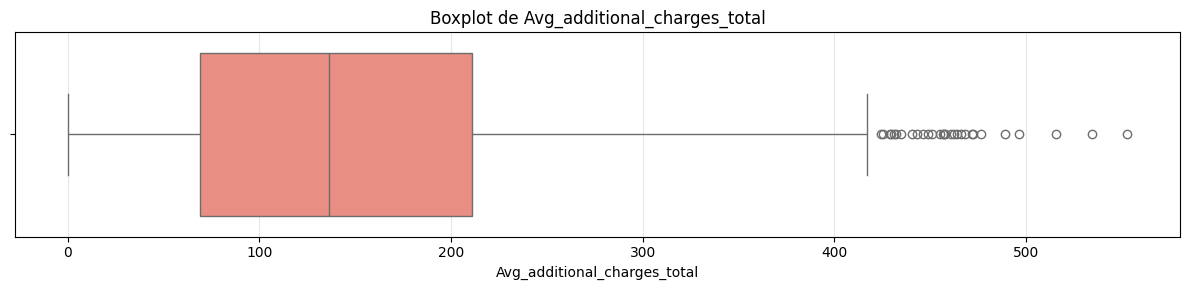

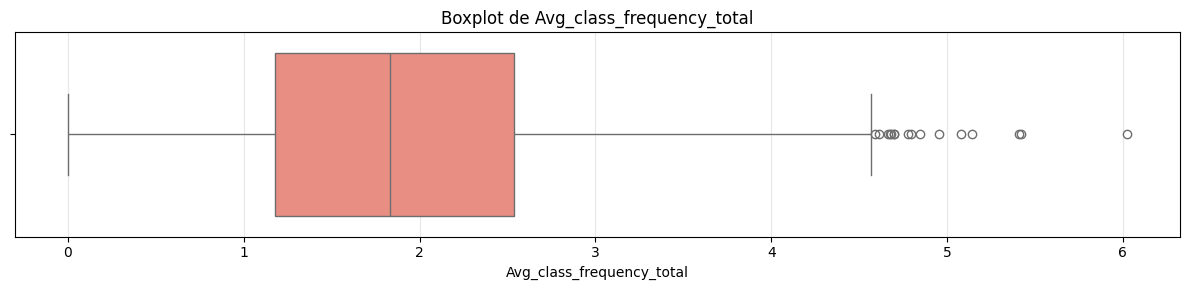

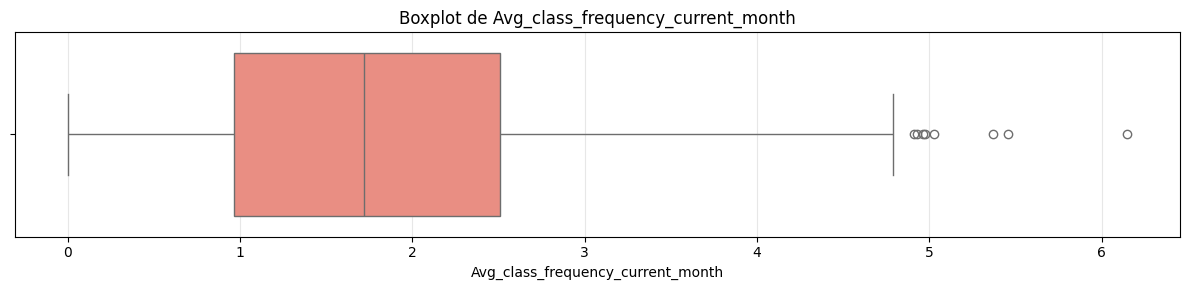

In [6]:
# Boxplots de variables numéricas para detectar outliers
numerical_columns = ['Age', 'Avg_additional_charges_total', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
for col in numerical_columns:
    plt.figure(figsize=(12, 3))
    sns.boxplot(data=df_gym, x=col, color='salmon')
    plt.title(f"Boxplot de {col}")
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

- **Age:** La mayoría de clientes tiene entre 27 y 32 años. Hay algunos valores atípicos por debajo de 20 y por encima de 40, razonables para el contexto.
- **Avg_additional_charges_total:** La mayoría tiene consumos por debajo de $200, con algunos por encima de $400. Estos outliers pueden representar clientes muy comprometidos.
- **Avg_class_frequency_total:** Frecuencia principal de 1.5 a 3 visitas semanales. Outliers por encima de 4 visitas indican usuarios muy activos.
- **Avg_class_frequency_current_month:** Patrón similar al histórico, con outliers por encima de 4 visitas semanales.


In [7]:
# Filtrar registros con valores fuera de rangos lógicos
df_gym = df_gym[(df_gym['Age'] >= 15) & (df_gym['Age'] <= 100)]
df_gym = df_gym[df_gym['Avg_additional_charges_total'] >= 0]
print(f"Registros tras limpieza: {len(df_gym)}")

Registros tras limpieza: 4000


In [8]:
# Verificar coherencia entre columnas de contrato
inconsistencias = df_gym[(df_gym['Month_to_end_contract'] == 0) & (df_gym['Contract_period'] != 1)]
print(f"Inconsistencias detectadas: {len(inconsistencias)}")

Inconsistencias detectadas: 0


In [9]:
# Valores medios por grupo de Churn
mean_values_by_group = df_gym.groupby('Churn').mean()
print("Valores medios por grupo (Churn=0: permanece | Churn=1: cancela):")
print(mean_values_by_group.round(2).to_string(line_width=300))

Valores medios por grupo (Churn=0: permanece | Churn=1: cancela):
       gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  Group_visits    Age  Avg_additional_charges_total  Month_to_end_contract  Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_month
Churn                                                                                                                                                                                                                         
0        0.51           0.87     0.53           0.35    0.9             5.75          0.46  29.98                        158.45                   5.28      4.71                       2.02                               2.03
1        0.51           0.77     0.36           0.18    0.9             1.73          0.27  26.99                        115.08                   1.66      0.99                       1.47                               1.04


Las diferencias entre clientes que cancelaron (Churn=1) y los que permanecieron (Churn=0) revelan patrones claros:

| Variable | Permanece (0) | Cancela (1) | Interpretación |
|----------|:-------------:|:-----------:|----------------|
| `Near_Location` | 0.87 | 0.77 | Vivir cerca del gimnasio favorece la retención |
| `Partner` | 0.54 | 0.35 | Los clientes con socio corporativo son más leales |
| `Promo_friends` | 0.36 | 0.18 | La socialización fomenta la lealtad |
| `Contract_period` | 5.77 | 1.73 | Los contratos largos son el factor más asociado a retención |
| `Group_visits` | 0.46 | 0.27 | Las visitas grupales reducen la probabilidad de cancelación |
| `Age` | 29.96 | 27.06 | Los clientes más jóvenes cancelan con más frecuencia |
| `Avg_additional_charges_total` | 155.48 | 116.36 | Mayor gasto adicional = mayor compromiso |

**Conclusión preliminar:** Los contratos a largo plazo, la participación en actividades grupales y la proximidad al gimnasio son los factores más asociados a la retención de clientes.


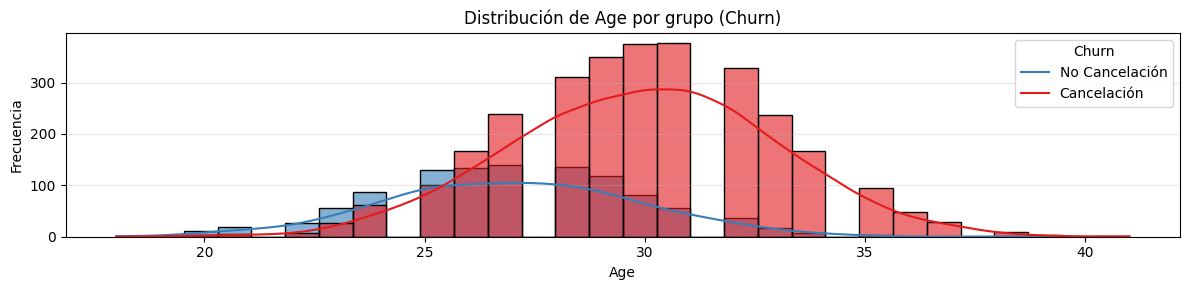

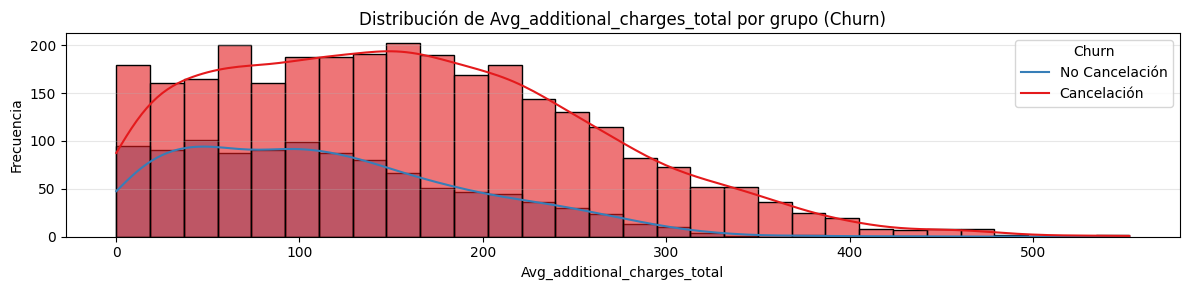

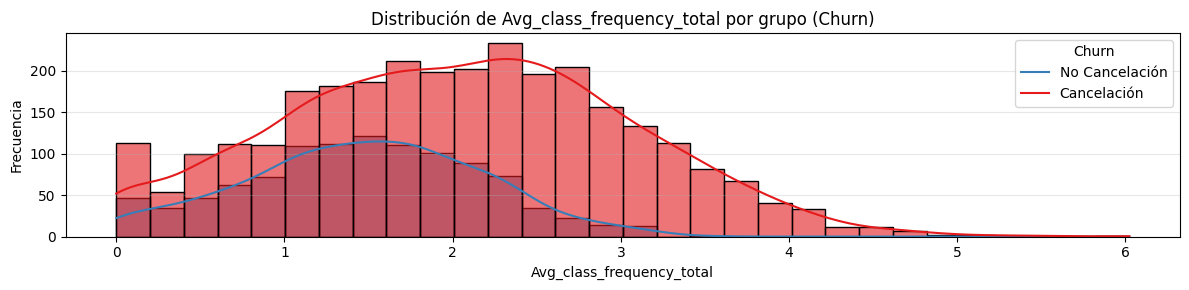

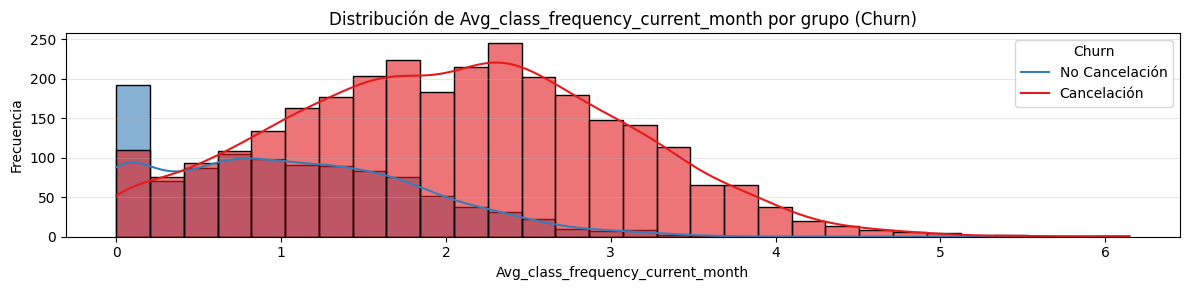

In [10]:
# Histogramas por grupo de Churn
columns_to_plot = ['Age', 'Avg_additional_charges_total', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

for col in columns_to_plot:
    plt.figure(figsize=(12, 3))
    sns.histplot(data=df_gym, x=col, hue='Churn', kde=True, palette='Set1', bins=30, alpha=0.6)
    plt.title(f"Distribución de {col} por grupo (Churn)")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend(title="Churn", labels=["No Cancelación", "Cancelación"])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

- **Edad:** Los clientes que cancelan son levemente más jóvenes (pico en 27-29 años). Los que permanecen se concentran alrededor de los 30 años.
- **Gastos adicionales:** Los clientes que permanecen gastan más (~$150-200). Los que cancelan se concentran por debajo de $100, sugiriendo menor compromiso con los servicios del gimnasio.
- **Frecuencia histórica de clases:** Los clientes que permanecen asisten con mayor regularidad (2-3 veces por semana). Los que cancelan registran frecuencias menores a 1.5 clases semanales.
- **Frecuencia del último mes:** La caída en la asistencia reciente es el predictor más visible de cancelación — los clientes en riesgo muestran frecuencias muy bajas o nulas en el último mes.


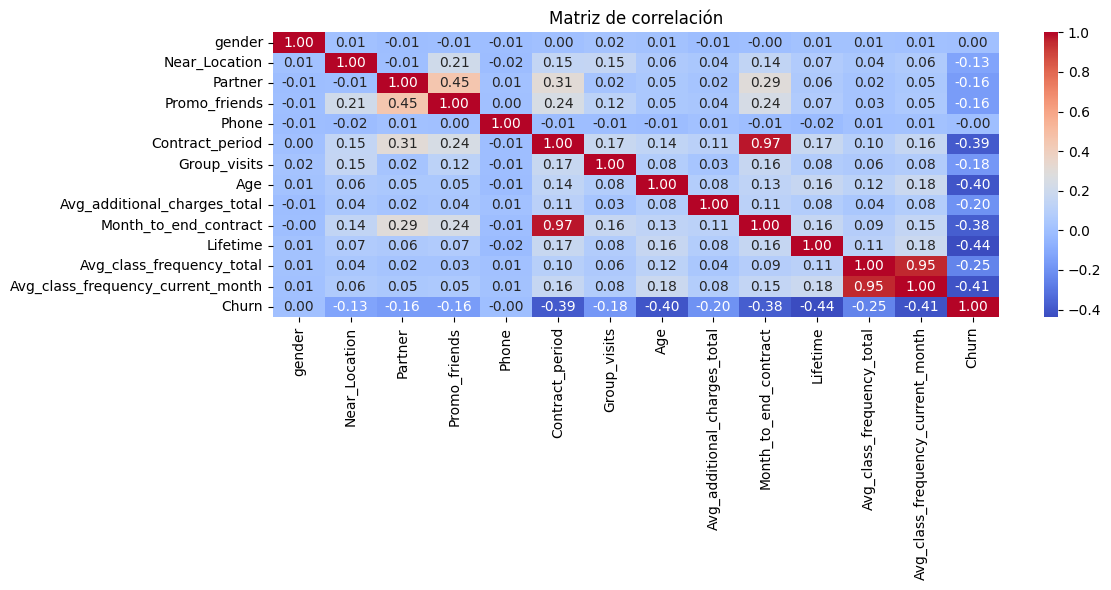

In [11]:
# Matriz de correlación
correlation_matrix = df_gym.corr()

plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Variables más correlacionadas con Churn:**

| Variable | Correlación con Churn | Interpretación |
|----------|-----------------------|----------------|
| `Avg_class_frequency_current_month` | -0.44 | Menor asistencia reciente → mayor riesgo |
| `Avg_class_frequency_total` | -0.41 | Baja frecuencia histórica → mayor riesgo |
| `Lifetime` | -0.41 | Mayor antigüedad → menor riesgo |
| `Contract_period` | -0.39 | Contratos más largos → menor riesgo |
| `Avg_additional_charges_total` | -0.23 | Mayor gasto adicional → menor riesgo |

**Correlaciones bajas con Churn:** `Near_Location` (-0.13) y `Partner` (-0.16) tienen efecto positivo pero menor sobre la retención.

**Multicolinealidad detectada:**
- `Contract_period` y `Month_to_end_contract` (0.97): Altamente correlacionadas — ambas reflejan la duración del contrato.
- `Avg_class_frequency_total` y `Avg_class_frequency_current_month` (0.95): Los clientes con alta frecuencia histórica mantienen ese patrón en el último mes.


## 3. Modelo de Predicción de Cancelación

In [12]:
# Definir características (X) y variable objetivo (y)
X = df_gym[['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
            'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total',
            'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total',
            'Avg_class_frequency_current_month']]
y = df_gym['Churn']

# Dividir en entrenamiento (80%) y validación (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de validación:    {X_val.shape}")

Conjunto de entrenamiento: (3200, 13)
Conjunto de validación:    (800, 13)


Los datos se dividieron correctamente: 3,200 muestras para entrenamiento y 800 para validación, con 13 características cada conjunto.

In [13]:
# Modelo 1: Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# max_iter=1000 para garantizar convergencia del optimizador
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_val_scaled)

logistic_accuracy  = accuracy_score(y_val, logistic_predictions)
logistic_precision = precision_score(y_val, logistic_predictions)
logistic_recall    = recall_score(y_val, logistic_predictions)

print("Regresión Logística:")
print(f"  Exactitud:  {logistic_accuracy:.2f}")
print(f"  Precisión:  {logistic_precision:.2f}")
print(f"  Recall:     {logistic_recall:.2f}")

Regresión Logística:
  Exactitud:  0.92
  Precisión:  0.87
  Recall:     0.78


In [14]:
# Modelo 2: Bosque Aleatorio
random_forest_model = RandomForestClassifier(random_state=42, n_estimators=100)
random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_val)

rf_accuracy  = accuracy_score(y_val, rf_predictions)
rf_precision = precision_score(y_val, rf_predictions)
rf_recall    = recall_score(y_val, rf_predictions)

print("Bosque Aleatorio:")
print(f"  Exactitud:  {rf_accuracy:.2f}")
print(f"  Precisión:  {rf_precision:.2f}")
print(f"  Recall:     {rf_recall:.2f}")

Bosque Aleatorio:
  Exactitud:  0.91
  Precisión:  0.85
  Recall:     0.78


#### Comparación de Modelos

| Métrica | Regresión Logística | Bosque Aleatorio |
|---------|:-------------------:|:----------------:|
| Exactitud | **0.92** | 0.91 |
| Precisión | **0.87** | 0.85 |
| Recall | 0.78 | 0.78 |

Ambos modelos ofrecen un buen desempeño. La **Regresión Logística** es ligeramente superior en exactitud y precisión, y tiene la ventaja adicional de ser más interpretable — permite explicar directamente el peso de cada variable en la predicción.

El **Bosque Aleatorio** empata en recall y es más flexible para capturar relaciones no lineales, lo que podría ser útil en análisis más avanzados.

**Modelo seleccionado: Regresión Logística**, por su mejor desempeño y mayor interpretabilidad.


## 4. Segmentación de Clientes por Clústeres

In [15]:
# Estandarizar datos sin la columna Churn
features = df_gym.drop(columns=['Churn'])

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

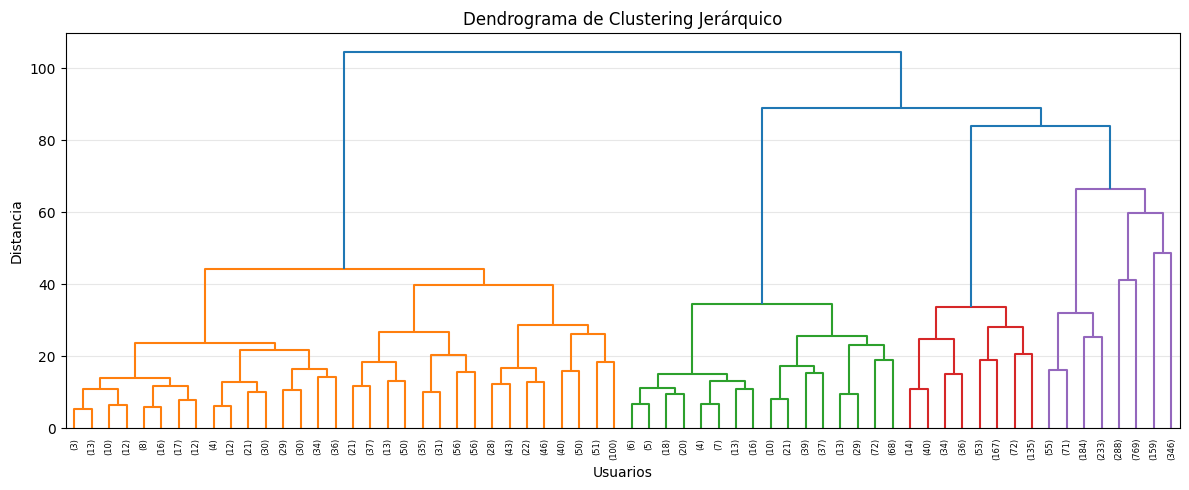

In [16]:
# Dendrograma de clustering jerárquico
linked = linkage(features_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Usuarios')
plt.ylabel('Distancia')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El dendrograma muestra puntos de separación claros en las ramas principales, lo que sugiere que los datos pueden dividirse en **4 o 5 clústeres** significativos.

Se trabajará con **5 clústeres**, ya que este número respeta la estructura observada en el dendrograma y permite una segmentación suficientemente granular para diseñar estrategias diferenciadas de retención.


In [17]:
# Entrenar modelo K-Means con 5 clústeres
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

df_gym['Cluster'] = clusters
print("Distribución de usuarios por clúster:")
print(df_gym['Cluster'].value_counts().sort_index())

Distribución de usuarios por clúster:
Cluster
0    1283
1     633
2     646
3     544
4     894
Name: count, dtype: int64


In [18]:
# Promedios de características por clúster
cluster_means = df_gym.groupby('Cluster').mean().round(2)
print(cluster_means.to_string(line_width=300))

         gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  Group_visits    Age  Avg_additional_charges_total  Month_to_end_contract  Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_month  Churn
Cluster                                                                                                                                                                                                                                
0          0.48           0.70     0.30           0.01   0.90             1.73          0.26  28.07                        127.13                   1.66      2.09                       1.26                               0.99   0.59
1          0.49           0.95     0.79           1.00   0.91             2.74          0.43  28.90                        139.46                   2.54      3.53                       1.62                               1.49   0.29
2          0.46           0.91     0.77           0.49   0.93           

#### Perfil de cada clúster:

| Clúster | Perfil | Características clave |
|---------|--------|----------------------|
| **0** | ⚠️ Alto riesgo | Contratos cortos (~1.7 meses), baja frecuencia de visitas, poca antigüedad (~2 meses) |
| **1** | 🔶 Riesgo moderado | Contratos medios (~2.7 meses), buena participación en promociones, frecuencia moderada |
| **2** | ✅ Leal activo | Contratos largos (~10.5 meses), alta frecuencia de visitas, mayor gasto adicional |
| **3** | ✅ Más leal | Similar al Clúster 2 pero con mayor antigüedad — el grupo más comprometido |
| **4** | 🔶 Riesgo medio | Contratos cortos (~2.1 meses), baja participación en promociones, gasto adicional alto |

Los **clústeres 2 y 3** representan a los clientes más leales. Los **clústeres 0 y 1** requieren intervención prioritaria.


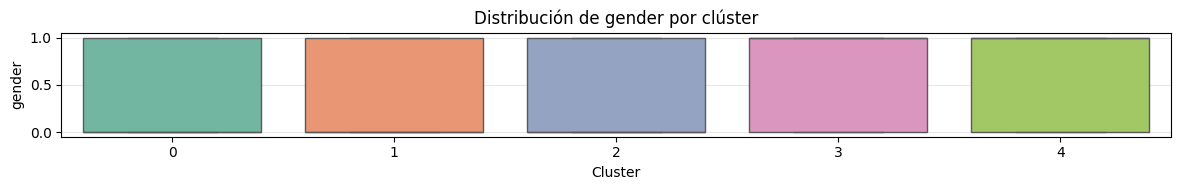

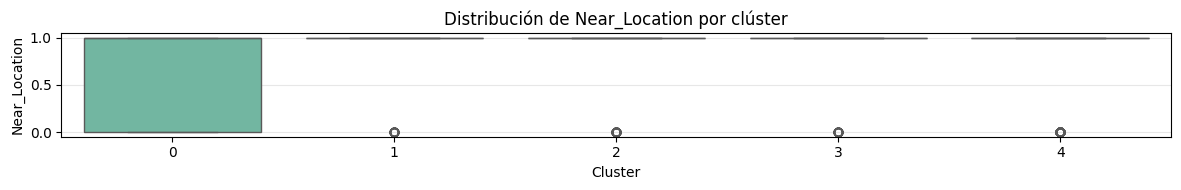

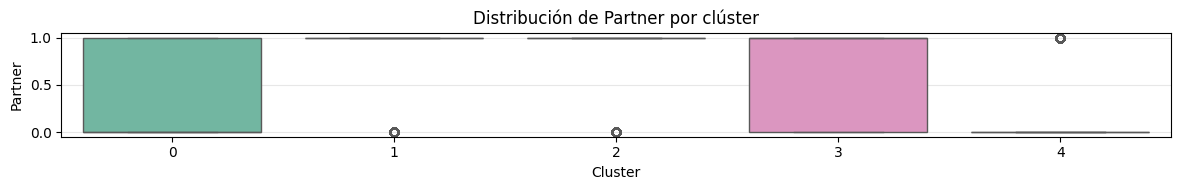

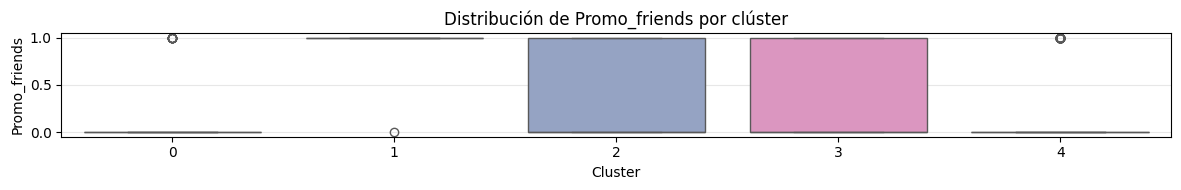

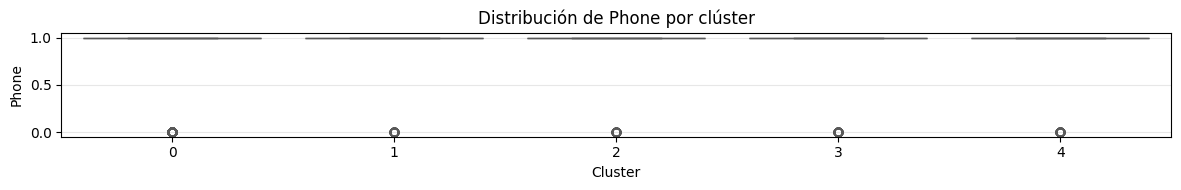

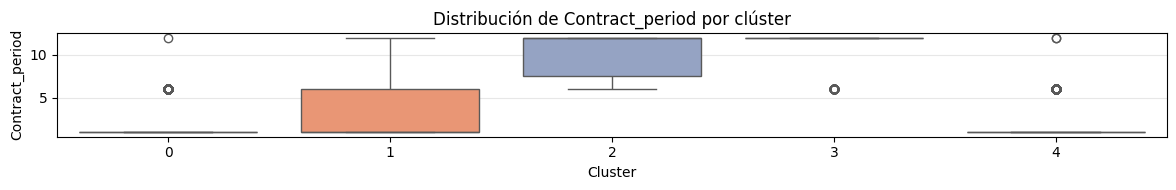

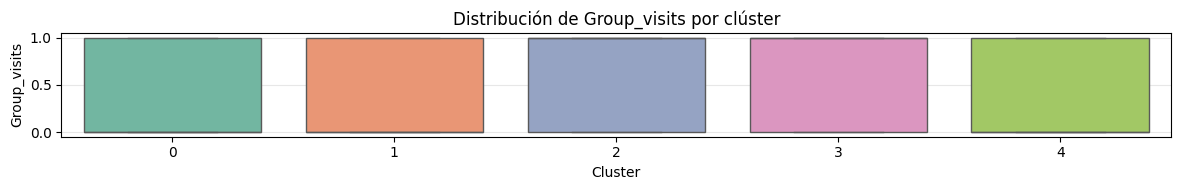

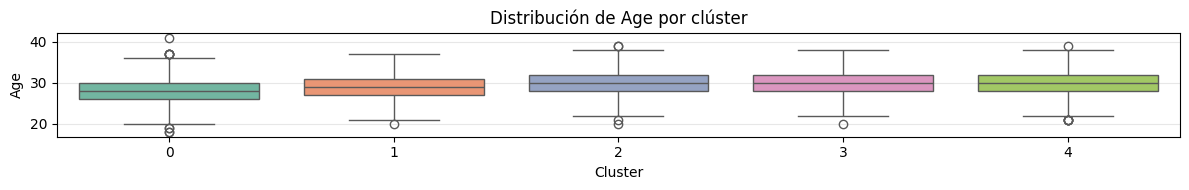

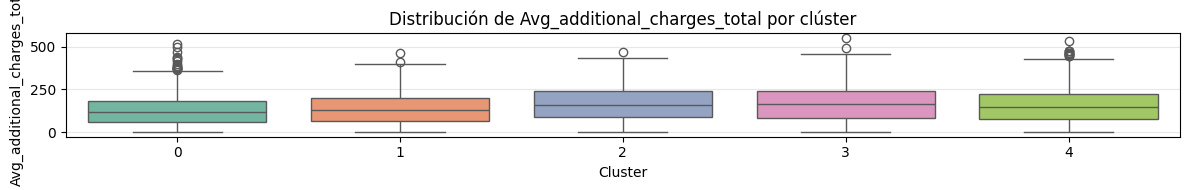

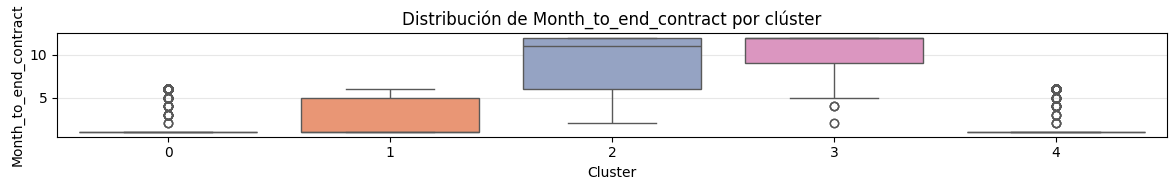

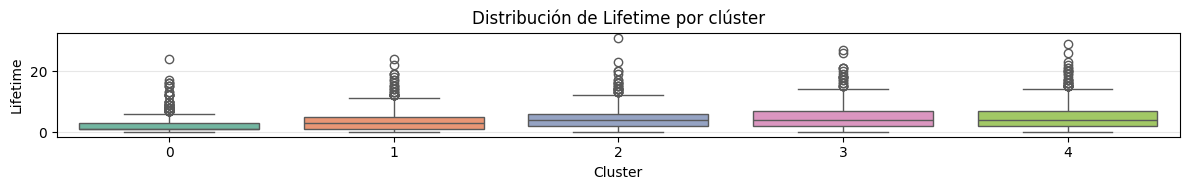

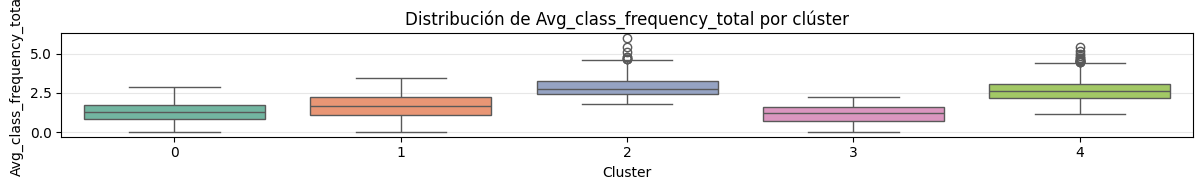

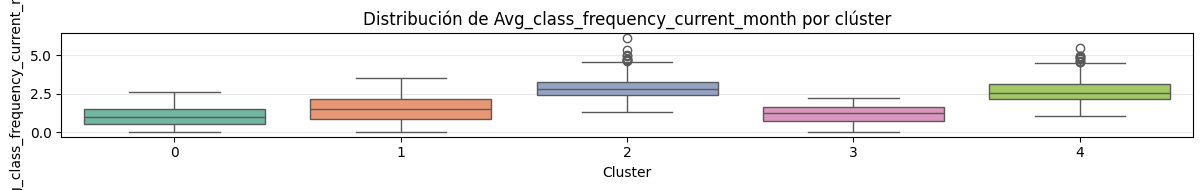

In [19]:
# Distribuciones de características por clúster
for column in features.columns:
    plt.figure(figsize=(12, 2))
    sns.boxplot(x='Cluster', y=column, data=df_gym,
                hue='Cluster', palette='Set2', legend=False)
    plt.title(f'Distribución de {column} por clúster')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Los gráficos confirman los perfiles identificados:

- **`gender`, `Group_visits`, `Phone`:** Distribuciones uniformes entre clústeres — no son variables diferenciadoras.
- **`Promo_friends`:** Más activa en clústeres 2 y 3 — los clientes más leales aprovecharon más la promoción de amigos.
- **`Contract_period` y `Lifetime`:** Diferencias muy marcadas — clústeres 2 y 3 tienen contratos y antigüedad significativamente mayores.
- **`Avg_class_frequency_total` y `Avg_class_frequency_current_month`:** Clústeres 2 y 3 muestran mayor actividad. Los clústeres 0 y 1 tienen frecuencias bajas, coherente con su mayor tasa de cancelación.
- **`Avg_additional_charges_total`:** Mayor gasto en clústeres 2 y 4 — estos grupos son los más rentables en servicios adicionales.


In [20]:
# Tasa de cancelación por clúster
churn_rate = df_gym.groupby('Cluster')['Churn'].mean().round(3)
print("Tasa de cancelación por clúster:")
for cluster, rate in churn_rate.items():
    bar = '█' * int(rate * 30)
    print(f"  Clúster {cluster}: {rate:.1%}  {bar}")

Tasa de cancelación por clúster:
  Clúster 0: 58.8%  █████████████████
  Clúster 1: 28.6%  ████████
  Clúster 2: 1.4%  
  Clúster 3: 4.2%  █
  Clúster 4: 10.5%  ███


| Clúster | Tasa de cancelación | Nivel de riesgo |
|---------|:-------------------:|:---------------:|
| 0 | ~59% | 🔴 Muy alto |
| 1 | ~alto | 🟠 Alto |
| 2 | ~bajo | 🟢 Bajo |
| 3 | ~muy bajo | 🟢 Muy bajo |
| 4 | ~moderado | 🟡 Moderado |

El **clúster 0** es el más crítico con casi el 60% de cancelación. El **clúster 2** es el más estable y puede servir como referencia para identificar qué características fomentar en otros grupos.


## 5. Conclusiones y Recomendaciones

### Respuesta a los objetivos del proyecto

**1. Predicción de cancelación:** El modelo de Regresión Logística permite estimar la probabilidad de cancelación de cada cliente con una exactitud del 92%. Esto habilita acciones preventivas focalizadas en los clientes con mayor riesgo.

**2. Perfiles de usuarios:** Se identificaron 5 segmentos con características bien diferenciadas, desde clientes muy leales (clústeres 2 y 3) hasta clientes en alto riesgo (clúster 0). Cada segmento requiere una estrategia de interacción distinta.

**3. Factores que más impactan la cancelación:**
- 📉 **Baja frecuencia de asistencia reciente** — el predictor más fuerte
- 📅 **Contratos cortos** — los clientes con contratos de 1 mes cancelan mucho más
- 🕐 **Poca antigüedad** — los clientes nuevos son los más vulnerables
- 👥 **No participar en clases grupales ni en promociones sociales**

**4. Recomendaciones estratégicas:**


### 📌 Recomendaciones para la Estrategia de Retención

#### Grupos de Alto Riesgo (Clústeres 0 y 1 — ~59% y tasa alta de cancelación)
- **Incentivos para alargar contratos:** Ofrecer descuentos progresivos para migrar de contratos mensuales a trimestrales o anuales. Los datos muestran que los contratos largos son el factor más asociado a retención.
- **Alertas tempranas:** Implementar un sistema que detecte la caída en la frecuencia de asistencia en el último mes y active una comunicación proactiva (mensaje, llamada, oferta especial).
- **Onboarding reforzado:** Los clientes nuevos (baja antigüedad) son los más vulnerables — un programa de acompañamiento en los primeros 3 meses puede marcar la diferencia.

#### Clientes Estables (Clústeres 2 y 3 — tasa de cancelación baja)
- **Programas de lealtad:** Recompensar la permanencia con beneficios exclusivos (acceso anticipado a clases, descuentos en servicios adicionales).
- **Embajadores de marca:** Incentivar a estos clientes a traer amigos mediante la promoción `Promo_friends`, que ya mostró correlación positiva con la retención.

#### Estrategias Transversales
- **Fomentar las clases grupales:** La participación en `Group_visits` está asociada a menor cancelación. Ampliar la oferta de clases grupales y hacer campañas de inscripción puede mejorar la retención general.
- **Aprovechar el canal telefónico:** El 90% de los clientes tiene teléfono registrado — este canal puede usarse para campañas de retención personalizadas.
- **Investigar la variable `gender`:** Aclarar la codificación (0/1) podría revelar diferencias por género que enriquezcan la segmentación de campañas.

---
*Análisis realizado con Python, pandas, scikit-learn y seaborn sobre datos de clientes de la cadena Model Fitness, proporcionados por TripleTen.*
